# Imports, Directories and constants

In [1]:
# Imports and formatting
import csv
import numpy as np
import h5py, json
import os, re, fnmatch
import pandas as pd
import matplotlib as mpl
import matplotlib.pyplot as plt
from itertools import cycle
from itertools import product
from datetime import datetime
from matplotlib.colors import LogNorm
from matplotlib.ticker import ScalarFormatter, FuncFormatter
from DiscEvolution.constants import *
from DiscEvolution.chemistry import *
from scipy.ndimage import uniform_filter1d
import matplotlib.ticker as ticker
from email import header

pd.set_option("display.max_colwidth", None)


In [2]:
# Directories
BASEDIR='/home/imontesd'
DATADIR=BASEDIR+'/output/DiscEvolution'
LITDATA=BASEDIR+'/output/DiscEvolution/litdata/'
CODEDIR=BASEDIR+'/DiscEvolution'
WORKINGDIR=BASEDIR+'/output/DiscEvolution/work/'
FIGDIR=BASEDIR+'/output/DiscEvolution/figures/'

# constants 
m_Jupiter = 317.8 # earth masses

# Chemistry
#solar_H_fraction=0.73 # by mass
X_H_solar = 0.73
X_He_solar = 0.25
mu_H = 1.0
mu_He = 4.0
mu_HHe = 2.3     # mean molecular weight of H+He mixture
Y_H = 0.92       # hydrogen fraction in primordial mixture
OH_solar = 0.00784 # mass
CH_solar = 0.00324 # mass
SiH_solar = 3.2e-5*28. # mass
CH_solar_number=CH_solar/12.
OH_solar_number=OH_solar/16.
SiH_solar_number=SiH_solar/28. 
OSi_solar_number=OH_solar_number/SiH_solar_number
Z_solar=0.02
SEC_PER_YEAR = 365.25 * 24.0 * 3600.0
ERAD_FIXED = 0.9
MU_GAS = 2.4


# key parameters
giant_thresh = 100  # Earth masses
psi_viscous = 0.01   # Viscous model psi value
psi_wind = 10       # Wind model psi value
# Define initial radius array 
initial_radii_au = [1, 2, 3, 4, 5, 7, 10, 15, 20, 25, 30]  # AUyr

# Global execution switches
GENERATE_PKL = False # Set to true to regenerate pkl files from output.  Slow.

# Main method to read .h5 output files 

In [3]:
# Method to read HDF5output files 
def load_data(fname, planets=False, dense_variables=None):
    """
    Load disc evolution output file (HDF5 only).
    
    Returns dict in JSON-equivalent format with consistent shapes.
    
    dense_variables : list[str] or None, optional
        Which "<name>_dense" datasets (see run_model_Hof_dense.py's
        DENSE_VARIABLES) to load out of the file, e.g. ["Sigma_G"].
        None (default) loads every dense variable present in the file --
        see load_data_dense() below for a wrapper that makes this
        argument required, if you always want to pick explicitly.
    """

    with h5py.File(fname, "r") as f:
        data = {}
        # Extract psi value from filename (e.g. "...psi0.01_erad0.9_Mdot...").
        # psi (= psi_DW) is the disc-wind mass-loss parameter. Units: dimensionless.
        psi = None
        m = re.search(r"psi([0-9.eE+-]+)", os.path.basename(fname))
        if m:
            psi = float(m.group(1))
        # Extract erad value from filename (e.g. "...psi0.01_erad0.9_Mdot...").
        # run_model_Hof.py::output_filename() writes the wind radiative-loss
        # efficiency into the filename as the token "erad" (the JSON config key
        # is "e_rad", with underscore) so it can be recovered here for the wind
        # mass-loss-rate calculation. Units: dimensionless fraction in [0, 1].
        # Same regex approach as psi above; stays None if the token is absent
        # (e.g. a file produced by the unmodified run_model_student.py).
        erad = None
        m = re.search(r"erad([0-9.eE+-]+)", os.path.basename(fname))
        if m:
            erad = float(m.group(1))
        # Scalars
        for key in ["t", "disk_Mdot_star", "disk_Mass", "Tc", "Sigc"]:
            if key in f:
                data[key] = f[key][()].tolist()
        data["alpha_SS"] = f.attrs.get("alpha_SS", None)
        data["psi"] = psi      # disc-wind mass-loss parameter psi_DW [dimensionless], from filename
        data["erad"] = erad    # wind radiative-loss efficiency e_rad [dimensionless, 0-1], from filename
        # Helper for ragged vs extendable vs single-dump
        def read_array(obj):
            if isinstance(obj, h5py.Dataset):       # dataset directly
                arr = obj[()]
                if np.ndim(arr) == 0:   # scalar
                    return [float(arr)]
                return np.array(arr).tolist()
            elif isinstance(obj, h5py.Group):       # ragged group
                vals = [obj[k][()] for k in sorted(obj.keys(), key=int)]
                return [float(v) for v in vals]
            else:
                raise TypeError(f"Unexpected type {type(obj)}")

        # ---------------- Per-planet arrays ----------------
        if (planets):
            data["Mcs"], data["Mes"], data["Rp"], data["disk_Mdot_p"] = [], [], [], []

            if isinstance(f.get("Mcs"), h5py.Dataset):
                # Single dataset case
                arr = np.array(f["Mcs"])
                data["Mcs"] = [row.tolist() if arr.ndim > 1 else [float(x)] for row in np.atleast_2d(arr)]
            else:
                for ip in sorted(f["Mcs"].keys(), key=int):
                    data["Mcs"].append(read_array(f["Mcs"][ip]))

            if isinstance(f.get("Mes"), h5py.Dataset):
                arr = np.array(f["Mes"])
                data["Mes"] = [row.tolist() if arr.ndim > 1 else [float(x)] for row in np.atleast_2d(arr)]
            else:
                for ip in sorted(f["Mes"].keys(), key=int):
                    data["Mes"].append(read_array(f["Mes"][ip]))

            if isinstance(f.get("Rp"), h5py.Dataset):
                arr = np.array(f["Rp"])
                data["Rp"] = [row.tolist() if arr.ndim > 1 else [float(x)] for row in np.atleast_2d(arr)]
            else:
                for ip in sorted(f["Rp"].keys(), key=int):
                    data["Rp"].append(read_array(f["Rp"][ip]))

            if isinstance(f.get("disk_Mdot_p"), h5py.Dataset):
                arr = np.array(f["disk_Mdot_p"])
                data["disk_Mdot_p"] = [row.tolist() if arr.ndim > 1 else [float(x)] for row in np.atleast_2d(arr)]
            else:
                for ip in sorted(f["disk_Mdot_p"].keys(), key=int):
                    data["disk_Mdot_p"].append(read_array(f["disk_Mdot_p"][ip]))
        # alpha_SS handling
        if "alpha_SS" in f.attrs:             # new streaming files
            data["alpha_SS"] = float(f.attrs["alpha_SS"])
        elif "alpha_SS" in f:                  # old single-dump files
            data["alpha_SS"] = f["alpha_SS"][()]
        else:
            data["alpha_SS"] = None
        # File attributes
        data["complete"] = f.attrs.get("complete", False)

        # ---------------- Chemistry ----------------
        if (planets):
            data["X_cores"], data["X_envs"] = [], []
            if "X_cores" in f:
                if isinstance(f["X_cores"], h5py.Dataset):
                    # Single dataset case — probably shaped (nplanets, nspecies, nsteps?)
                    arr_core = np.array(f["X_cores"])
                    arr_env  = np.array(f["X_envs"])
                    nplanets = arr_core.shape[0]
                    for ip in range(nplanets):
                        core_species = [arr_core[ip, js, :].tolist() for js in range(arr_core.shape[1])]
                        env_species  = [arr_env[ip, js, :].tolist()  for js in range(arr_env.shape[1])]
                        data["X_cores"].append(core_species)
                        data["X_envs"].append(env_species)
                else:
                    # Group → streaming or ragged format
                    for ip in sorted(f["X_cores"].keys(), key=int):
                        core_species = []
                        env_species  = []
                        for js in sorted(f["X_cores"][ip].keys(), key=int):
                            core_species.append(read_array(f["X_cores"][ip][js]))
                        for js in sorted(f["X_envs"][ip].keys(), key=int):
                            env_species.append(read_array(f["X_envs"][ip][js]))
                        data["X_cores"].append(core_species)
                        data["X_envs"].append(env_species)


        # ---------------- Disk profiles ----------------
        if "R" in f:
            data["R"] = f["R"][:].tolist()
        else:
            nR = f["Sigma_G"].shape[1]
            data["R"] = list(range(nR))  # placeholder if R not saved

        for key in ["Sigma_G", "Sigma_dust", "Sigma_pebbles", "T", "Sigma_pebble_size", "Vdrift"]:
            if key in f:
                data[key] = f[key][:].tolist()
        if "Sigma_planetesimals" in f:
            data["Sigma_planetesimals"] = f["Sigma_planetesimals"][:].tolist()
        # Dense-cadence profile(s), only present in run_model_Hof_dense.py
        # output (filename contains "_dense_"). run_model_Hof_dense.py's
        # DENSE_VARIABLES list controls how many/which observables get a
        # "<name>_dense" / "<name>_dense_t" dataset pair -- e.g. the current
        # config exports THREE (Sigma_G, Sigma_dust, Sigma_pebbles). First
        # find every "<name>_dense"/"<name>_dense_t" pair actually present in
        # the file, then keep only the ones dense_variables asked for (or all
        # of them, if dense_variables is None -- the default). Each
        # "<name>_dense" is a (n_dense, nR) array that can be hundreds of MB,
        # so passing an explicit dense_variables list (or using
        # load_data_dense() below) avoids loading the ones you don't need.
        # Each "<name>_dense" has one row per write inside the
        # [DENSE_T_MIN_MYR, DENSE_T_MAX_MYR] window that run used (see
        # run_model_Hof_dense.py), NOT one row per time_snap entry -- so it
        # does NOT align with Sigma_G/time_snap, and generally has far more
        # rows. "<name>_dense_t" [years] is its own matching per-row
        # timestamp; use that, not time_snap, to plot/index into "<name>_dense".
        available_dense = sorted(
            k[: -len("_dense")] for k in f.keys()
            if k.endswith("_dense") and f"{k}_t" in f
        )
        if dense_variables is None:
            dense_names = available_dense
        else:
            missing = [name for name in dense_variables if name not in available_dense]
            if missing:
                print(f"load_data: requested dense_variables {missing} not found in "
                      f"{os.path.basename(fname)} (available: {available_dense}) -- skipping")
            dense_names = [name for name in dense_variables if name in available_dense]
        data["dense_names"] = dense_names   # e.g. ["Sigma_G"] if dense_variables=["Sigma_G"]
        for _dname in dense_names:
            data[f"{_dname}_dense"] = f[f"{_dname}_dense"][:].tolist()
            data[f"{_dname}_dense_t"] = f[f"{_dname}_dense_t"][:].tolist()
        if "time_snap" in f:
            data["time_snap"] = f["time_snap"][:].tolist()
        # Extract ice line locations (water ice line)
        if "disk_ice_lines" in f:
            data["disk_ice_lines"] = f["disk_ice_lines"][:].tolist()
        chemdata=True
        try:
            for key in ["disk_atom_gas_abund", "disk_mol_gas_abund",
                        "disk_atom_ice_abund", "disk_mol_ice_abund",
                        "disk_planetesimal_atom_abund", "disk_planetesimal_mol_abund"]:
                if key in f:
                    data[key] = np.array(f[key][:], dtype=float).tolist()
        except:
            chemdata=False


    # ---------------- Normalize shapes ----------------
    data["R"] = np.array(data["R"], dtype=float).squeeze()  # always (nR,)

    for key in ["Sigma_G", "Sigma_dust", "Sigma_pebbles", "Sigma_planetesimals", "T", "Sigma_pebble_size"]:
        if key in data:
            arr = np.array(data[key], dtype=float)
            arr = np.atleast_2d(arr)          # (nsnapshots, nR)
            if arr.ndim == 3 and arr.shape[1] == 1:
                arr = arr[:, 0, :]           # squeeze accidental middle dim
            data[key] = arr

    # Ensure R is always 1D
    data["R"] = np.array(data["R"], dtype=float)

    if data["R"].ndim == 2:
        # Old HDF5 case: R repeated for each snapshot
        # Keep just one copy (they should all be identical)
        data["R"] = data["R"][0, :]

    data["R"] = data["R"].squeeze()


    # Normalize disk profile arrays to (nsnap, nR)
    for key in ["Sigma_G", "Sigma_dust", "Sigma_pebbles", "Sigma_planetesimals", "T", "Sigma_pebble_size"]:
        if key in data:
            arr = np.array(data[key], dtype=float)
            arr = np.atleast_2d(arr)  # (nsnap, nR)
            if arr.ndim == 3 and arr.shape[1] == 1:
                arr = arr[:, 0, :]
            data[key] = arr
    if "time_snap" in data:
        data["time_snap"] = np.array(data["time_snap"], dtype=float)
    # "<name>_dense" / "<name>_dense_t" for every densely-exported observable
    # (see dense_names, set above): (n_dense, nR) / (n_dense,) arrays, NOT tied
    # to time_snap's length -- see comment where these are read, above.
    for _dname in data.get("dense_names", []):
        data[f"{_dname}_dense"] = np.atleast_2d(np.array(data[f"{_dname}_dense"], dtype=float))   # native units, e.g. g/cm^2 for Sigma_*
        data[f"{_dname}_dense_t"] = np.array(data[f"{_dname}_dense_t"], dtype=float)              # [years]
    # Normalize disk_ice_lines to (nsnap, nR)
    if "disk_ice_lines" in data:
        arr = np.array(data["disk_ice_lines"], dtype=float)
        arr = np.atleast_2d(arr)  # (nsnap, nR)
        if arr.ndim == 3 and arr.shape[1] == 1:
            arr = arr[:, 0, :]
        data["disk_ice_lines"] = arr
    if (chemdata):
        for key in ["disk_atom_gas_abund", "disk_mol_gas_abund",
                    "disk_atom_ice_abund", "disk_mol_ice_abund",
                    "disk_planetesimal_atom_abund", "disk_planetesimal_mol_abund"]:
            if key in data:
                arr = np.array(data[key], dtype=float)
                # Expected shape: (nsnap, Nspecies, nR)
                if arr.ndim == 2:  # in case nsnap=1
                    arr = arr[np.newaxis, ...]
                data[key] = arr

    return data


## Dense-variable-selective loader


In [4]:
# Wrapper around load_data() for when you want to explicitly choose which
# dense variables get loaded, rather than relying on load_data()'s default
# of loading every "<name>_dense" pair present in the file.
#
# Why this exists: a dense HDF5 file (run_model_Hof_dense.py output, filename
# contains "_dense_") can export several observables at once -- see that
# file's DENSE_VARIABLES list, currently ["Sigma_G", "Sigma_dust",
# "Sigma_pebbles"]. Each is a (n_dense, nR) float64 array -- for the
# 22311 x 1000 dense grid in the currently-loaded file that's ~180 MB raw per
# variable, ~1.6 GB combined once round-tripped through Python lists inside
# load_data() -- so loading all of them when you only need one or two wastes
# memory (and contributed to a full-notebook `nbconvert --execute` getting
# OOM-killed on this box's ~4.5 GB available RAM).
#
# dense_variables is a REQUIRED argument here (unlike load_data(), where it's
# optional and None means "load everything") specifically so a call site
# reads as "the loader that only pulls these dense variables", e.g.:
#   data = load_data_dense(path, dense_variables=["Sigma_G"])
# Any name not present in the file is skipped with a printed warning (see
# load_data()'s dense-loading block for the exact matching logic).
def load_data_dense(fname, dense_variables, planets=False):
    return load_data(fname, planets=planets, dense_variables=dense_variables)


## Other helper functions

In [5]:
# === OTHER HELPER FUNCTIONS ===
# Compute essential quantities used throughout analysis

def extract_disk_mass_from_filename(filename):
    """
    Extract initial disk mass from filename pattern (e.g., "_M1.5e-01" -> 0.15 solar masses).
    """
    if pd.isna(filename):
        return np.nan
    
    # Pattern like "_M5.0e-02" for 0.05 solar masses
    m_match = re.search(r'_M([0-9.eE+-]+)', filename)
    if m_match:
        return float(m_match.group(1))  # Solar masses
    else:
        return np.nan

def extract_e_rad_from_filename(filename):
    return None

def integrate_surface_density_mass(sim_data, sigma_key):
    """
    Integrate total mass from surface density profile:
        M = 2*pi * integral[ Sigma(R) * R dR ]
    Sigma in g/cm^2, R in AU.
    Returns mass in grams as a function of time.
    """
    if sigma_key not in sim_data:
        raise KeyError(f"{sigma_key} not found in sim_data")

    # Radius key fallback
    if "R" in sim_data:
        R_au = np.asarray(sim_data["R"], dtype=float)
    elif "Rc" in sim_data:
        R_au = np.asarray(sim_data["Rc"], dtype=float)
    else:
        raise KeyError("No radial grid found (expected sim_data['R'] or sim_data['Rc']).")

    Sigma = np.asarray(sim_data[sigma_key], dtype=float)
    R_cm = R_au * AU

    if Sigma.ndim == 1:
        # Single snapshot
        M_g = 2.0 * np.pi * np.trapezoid(Sigma * R_cm, R_cm)
        return np.array([M_g], dtype=float)

    if Sigma.ndim != 2:
        raise ValueError(f"Unexpected shape for {sigma_key}: {Sigma.shape}")

    nr = R_cm.size
    if Sigma.shape[-1] == nr:
        # Shape (nt, nr)
        M_g = 2.0 * np.pi * np.trapezoid(Sigma * R_cm[None, :], R_cm, axis=1)
    elif Sigma.shape[0] == nr:
        # Shape (nr, nt)
        M_g = 2.0 * np.pi * np.trapezoid(Sigma * R_cm[:, None], R_cm, axis=0)
    else:
        raise ValueError(f"Cannot align {sigma_key} shape {Sigma.shape} with R shape {R_cm.shape}")

    return np.asarray(M_g, dtype=float)

def _format_psi(psi):
    # Match your existing naming convention: 0.01, 10.0, etc.
    return f"{psi:.2f}" if psi < 1 else f"{psi:.1f}"

def _format_sci(x):
    # Match 1.0e-09, 5.0e-02, 5.0e+01 style
    return f"{float(x):.1e}"

def _make_filename(psi, mdot, m, rd):
    psi_str = _format_psi(float(psi))
    return (
        f"winds_mig_psi{psi_str}_"
        f"Mdot{_format_sci(mdot)}_"
        f"M{_format_sci(m)}_"
        f"Rd{_format_sci(rd)}.h5"
    )

def build_file_lists(
    mdot_values,
    m_values,
    rd_values,
    psi_viscous=psi_viscous,
    psi_wind=psi_wind,
    datadir=None,
    keep_only_existing=False
):
    combos = list(product(mdot_values, m_values, rd_values))

    visc = tuple(_make_filename(psi_viscous, mdot, m, rd) for mdot, m, rd in combos)
    wind = tuple(_make_filename(psi_wind,    mdot, m, rd) for mdot, m, rd in combos)

    if keep_only_existing:
        if datadir is None:
            raise ValueError("datadir must be provided when keep_only_existing=True")

        visc = tuple(f for f in visc if os.path.exists(os.path.join(datadir, f)))
        wind = tuple(f for f in wind if os.path.exists(os.path.join(datadir, f)))

    return visc, wind

def _as_snapshot_matrix(arr, nr, name):
    a = np.asarray(arr, dtype=float)
    if a.ndim == 1:
        if a.size != nr:
            raise ValueError(f"{name} has length {a.size}, expected {nr}")
        a = a[None, :]

    elif a.ndim == 2:
        if a.shape[-1] == nr:
            pass
        elif a.shape[0] == nr:
            a = a.T
        else:
            raise ValueError(f"Cannot align {name} shape {a.shape} with nr={nr}")

    else:
        raise ValueError(f"Unexpected {name} ndim={a.ndim}")

    return a

def _interpolate_mdot_star_to_snapshots(sim_data, t_snap):
    t_mdot = np.asarray(sim_data.get("t", []), dtype=float)
    mdot = np.asarray(sim_data.get("disk_Mdot_star", []), dtype=float)
    if t_mdot.size == 0 or mdot.size == 0:
        raise KeyError("sim_data must include 't' and 'disk_Mdot_star'")

    n = min(t_mdot.size, mdot.size)
    t_mdot = t_mdot[:n]
    mdot = mdot[:n]

    # If t is in years while snapshots are in Myr, convert t for interpolation.
    if np.nanmax(t_mdot) > 1.0e3 and np.nanmax(t_snap) < 1.0e2:
        t_mdot_use = t_mdot / 1.0e6
    else:
        t_mdot_use = t_mdot

    return np.interp(t_snap, t_mdot_use, mdot, left=np.nan, right=np.nan)

def integrate_wind_mass_loss_rate(sim_data, erad=ERAD_FIXED, mu=MU_GAS):
    """
    Integrate wind mass-loss rate over radius at each snapshot and return:
    x = stellar accretion rate at snapshot times [Msun/yr]
    y = integrated wind loss rate [Msun/yr]
    """
    if "R" in sim_data:
        R_au = np.asarray(sim_data["R"], dtype=float).squeeze()
    elif "Rc" in sim_data:
        R_au = np.asarray(sim_data["Rc"], dtype=float).squeeze()
    else:
        raise KeyError("No radial grid found (expected sim_data['R'] or sim_data['Rc'])")
    if "Sigma_G" not in sim_data or "T" not in sim_data:
        raise KeyError("sim_data must include 'Sigma_G' and 'T'")

    psi = float(sim_data.get("psi", np.nan))
    alpha_ss = float(sim_data.get("alpha_SS", np.nan))
    if not np.isfinite(psi) or not np.isfinite(alpha_ss) or psi <= 0.0:
        raise ValueError(f"Invalid psi/alpha_SS: psi={psi}, alpha_SS={alpha_ss}")

    # alpha_DW / alpha_SS = psi
    alpha_dw = psi * alpha_ss

    nr = R_au.size
    Sigma = _as_snapshot_matrix(sim_data["Sigma_G"], nr, "Sigma_G")
    Temp = _as_snapshot_matrix(sim_data["T"], nr, "T")

    t_snap = np.asarray(sim_data.get("time_snap", []), dtype=float)
    if t_snap.size == 0:
        raise KeyError("sim_data must include 'time_snap' to align with disk_Mdot_star")

    ns = min(t_snap.size, Sigma.shape[0], Temp.shape[0])
    t_snap = t_snap[:ns]
    Sigma = Sigma[:ns, :]
    Temp = Temp[:ns, :]

    R_cm = R_au * AU
    Omega_K = Omega0 * np.power(R_au, -1.5)  # Solar-mass star
    cs2 = (GasConst / mu) * Temp

    # dotSigma_w = (3/2)*(cs^2/(Omega*R^2))*(1-erad)*alpha_DW*Sigma*(3/psi + 1)
    prefac = 1.5 * (1.0 - erad) * alpha_dw * (3.0 / psi + 1.0)
    sigma_dot_w = prefac * (cs2 / (Omega_K[None, :] * R_cm[None, :]**2)) * Sigma

    # dotM_w = 2*pi*integral(dotSigma_w * R dR)
    mdot_w_g_per_s = 2.0 * np.pi * np.trapezoid(sigma_dot_w * R_cm[None, :], R_cm, axis=1)
    mdot_w_msun_per_yr = mdot_w_g_per_s * SEC_PER_YEAR / Msun

    mdot_star_snap = _interpolate_mdot_star_to_snapshots(sim_data, t_snap)

    ok = np.isfinite(mdot_star_snap) & np.isfinite(mdot_w_msun_per_yr)
    ok &= (mdot_star_snap > 0.0) & (mdot_w_msun_per_yr > 0.0)

    return mdot_star_snap[ok], mdot_w_msun_per_yr[ok], t_snap[:ns][ok]

# Custom formatter to show integers without decimals and no scientific notation
def custom_formatter(x, pos):
    try:
        # Better integer detection - check if the value is very close to an integer
        if abs(x - round(x)) < 1e-10:
            return f'{int(round(x))}'
        elif x >= 1:
            return f'{x:.1f}'
        elif x >= 0.1:
            return f'{x:.1f}'
        else:
            return f'{x:.2f}'
    except (TypeError, ValueError, OverflowError):
        # Fallback for any problematic values
        return f'{x}'

def _parse_float(s):
    s = s.strip()
    if s == "":
        return np.nan
    try:
        return float(s)
    except ValueError:
        return np.nan

def _first_scalar(v):
    if isinstance(v, (list, tuple, np.ndarray, pd.Series)):
        return v[0]
    return v


def _extract_column_first(df_obj, candidates):
    for col in candidates:
        if col in df_obj.columns:
            return df_obj[col].apply(_first_scalar)
    raise KeyError(f"None of these columns found: {candidates}")
print("✅ HELPER FUNCTIONS defined successfully!")

✅ HELPER FUNCTIONS defined successfully!


# ----- INSERT FILENAME HERE -----
# Extract and Calculate Observables from data

In [6]:
# Extract Data from output file
filename = 'hof_discwind_gamma0.375_dense_psi0.01_erad0.9_Mdot1.0e-08_M1.0e-02_Rd5.0e+01.h5'

data = load_data(os.path.join(DATADIR, filename), dense_variables = ["Sigma_G"])


## t
## t_Myr
## t_snap
## Mdisc_t
## Mdot_t

In [7]:
#Extract different quantities from the data

# Time grid
t = data["t"]
print('t extracted successfully')

t_Myr = np.asarray(t, dtype=float) / 1e6

# Snapshot grid
t_snap = data["time_snap"]
print('t_snap extracted successfully')

# Disc Mass
Mdisc_t = data["disk_Mass"]                     # Note this is total mass, gas+dust. 
                                                # gas mass is calculated in cell below
print('Disc Mass extracted successfully')

# Mdot (accretion onto star)
Mdot_t = data["disk_Mdot_star"]
print('Mdot extracted successfully')


t extracted successfully
t_snap extracted successfully
Disc Mass extracted successfully
Mdot extracted successfully


## Mgas_tsnap

In [8]:
# Calculate gas mass 

from DiscEvolution.constants import AU, Msun
R = np.asarray(data["R"])          # AU
Mgas_tsnap = np.array([
    np.trapezoid(sigma_g_row * 2*np.pi*R, R) * AU**2 / Msun   # Msun
    for sigma_g_row in data["Sigma_G"]
])

print("Mgas_tsnap calculated successfully")
# Mgas_t is given in sun masses
# Does not exactly replicate integration approach from AccretionDisc.Mtot() in disc.py
# Variable can be used to study trends but do not use for "exact consistency" (HOF_PROJECT_GUIDE.md)

Mgas_tsnap calculated successfully


## erad
## t_snap_mask
## Mdot_tsnap
## Mdot_tsnap_mask
## Mdot_wind_tsnap_mask

In [9]:
# Extract Mdot_wind using given post-processing tool

erad = data["erad"]                                              # wind radiative-loss efficiency [dimensionless, 0-1]
print("erad extracted successfully")

Mdot_tsnap = _interpolate_mdot_star_to_snapshots(data, t_snap)   # stellar accretion rate [Msun/yr] at each t_snap [Myr]

print("Mdot_tsnap calculated successfully")

# Use this run's own erad (recovered from the filename by load_data), NOT the
# ERAD_FIXED default baked into integrate_wind_mass_loss_rate().

# integrate_wind_mass_loss_rate() drops any snapshot where EITHER rate is NaN
# (accretion interpolated outside the recorded t-range) or <= 0 (decretion /
# empty outer disc). The SAME mask is applied to both rate outputs, so they stay
# paired; the arrays are possibly SHORTER than t_snap. It also returns t_snap_mask,
# the matching snapshot times [Myr] for the kept points, so the masked rates can
# still be plotted against time. All three returned arrays have equal length.
#   Mdot_tsnap_mask       stellar accretion rate      [Msun/yr]
#   Mdot_wind_tsnap_mask   integrated disc-wind loss   [Msun/yr]
#   t_snap_mask            snapshot times (kept)       [Myr]

if data["psi"] != 0:    
    Mdot_tsnap_mask , Mdot_wind_tsnap_mask, t_snap_mask = integrate_wind_mass_loss_rate(data, erad)
    print("Mdot_tsnap_mask, Mdot_wind_tsnap_mask calculated successfully")
else:
    Mdot_tsnap_mask , Mdot_wind_tsnap_mask, t_snap_mask = None, None, None
    print("Simulation follows purely viscous model, no wind mass loss rate to be calculated")


# Might require some tinkering upstream 
# in '_integrate()' or 'write_disc_snapshot()' in run_model_student.py


erad extracted successfully
Mdot_tsnap calculated successfully
Mdot_tsnap_mask, Mdot_wind_tsnap_mask calculated successfully


In [10]:
# --- Diagnostic: which snapshots does integrate_wind_mass_loss_rate()'s mask drop? ---
#
# The function keeps a snapshot only if BOTH rates are finite and > 0, but it does
# not report which snapshots it removed. Here we recompute BOTH rates for EVERY
# snapshot (no mask), mirroring the function's math exactly, and tabulate the mask
# conditions per snapshot so the dropped points and their reason are visible.
#
# Units (mirrors integrate_wind_mass_loss_rate):
#   _R        cell-centre radii              [AU]              data["R"]
#   _Sig      gas surface density            [g/cm^2]          data["Sigma_G"], one row per t_snap
#   _T        midplane temperature           [K]               data["T"],       one row per t_snap
#   _psi      disc-wind mass-loss parameter  [dimensionless]
#   _assp     viscous alpha (alpha_SS)       [dimensionless]
#   _erad     wind radiative-loss efficiency [dimensionless, 0-1]
#   _Rcm      radii                          [cm]
#   _OmK      Keplerian angular frequency    [rad/s]           Omega0 = 2*pi / (1 yr in s)
#   _cs2      sound speed squared            [cm^2/s^2]        (R_gas / mu) * T
#   _sdw      local wind mass-loss rate      [g/cm^2/s]
#   mdot_wind_all  2*pi * integral(_sdw * R dR) = [g/s]  ->  * SEC_PER_YEAR / Msun  ->  [Msun/yr]
#   mdot_star_all  stellar accretion rate at each snapshot                            [Msun/yr]
#
# Mask keeps a snapshot iff:  Mdot_star finite & > 0  AND  Mdot_wind finite & > 0.

_R   = np.asarray(data["R"], dtype=float)          # [AU]
_Sig = np.asarray(data["Sigma_G"], dtype=float)    # [g/cm^2], shape (nsnap, nR)
_T   = np.asarray(data["T"], dtype=float)          # [K],      shape (nsnap, nR)
_ns  = min(t_snap.size, _Sig.shape[0], _T.shape[0])   # same pre-mask row cut the function makes

_psi, _assp, _erad = float(data["psi"]), float(data["alpha_SS"]), float(data["erad"])   # all dimensionless
_Rcm  = _R * AU                                                             # [cm]
_OmK  = Omega0 * _R**-1.5                                                   # [rad/s]  (Solar-mass star)
_cs2  = (GasConst / MU_GAS) * _T[:_ns]                                      # [cm^2/s^2]
if _psi != 0:
    _pref = 1.5 * (1.0 - _erad) * (_psi * _assp) * (3.0 / _psi + 1.0)          # [dimensionless]
    _sdw  = _pref * (_cs2 / (_OmK[None, :] * _Rcm[None, :]**2)) * _Sig[:_ns]   # [g/cm^2/s]
    mdot_wind_all = 2*np.pi * np.trapezoid(_sdw * _Rcm[None, :], _Rcm, axis=1) * SEC_PER_YEAR / Msun  # [Msun/yr]
else:
    _sdw = 0
    mdot_wind_all = 0

mdot_star_all = _interpolate_mdot_star_to_snapshots(data, t_snap[:_ns])                           # [Msun/yr]

# Make dataframe with booleans for each snapshot evaluating if datapoint is kept by mask or not
diag = pd.DataFrame({
    "t_snap_Myr":    t_snap[:_ns],       # [Myr]
    "Mdot_star":     mdot_star_all,      # [Msun/yr]
    "Mdot_wind":     mdot_wind_all,      # [Msun/yr]
    "star_finite":   np.isfinite(mdot_star_all),
    "star_positive": mdot_star_all > 0,
    "wind_finite":   np.isfinite(mdot_wind_all),
    "wind_positive": mdot_wind_all > 0,
})
diag["kept"] = diag[["star_finite", "star_positive", "wind_finite", "wind_positive"]].all(axis=1)

# Determine why a datapoint might have been flagged and removed
def _why(r):
    if r["kept"]:
        return ""
    reasons = []
    if not r["star_finite"]:       reasons.append("Mdot_star NaN/inf (accretion interp outside recorded t-range)")
    elif not r["star_positive"]:   reasons.append("Mdot_star <= 0")
    if not r["wind_finite"]:       reasons.append("Mdot_wind NaN/inf")
    elif not r["wind_positive"]:   reasons.append("Mdot_wind <= 0")
    return "; ".join(reasons)

diag["drop_reason"] = diag.apply(_why, axis=1)

# Distinguish how many points might have been dropped by mask vs. how many might have been truncated by array length > _ns
print(f"snapshots after ns-cut: {_ns}   kept: {int(diag['kept'].sum())}   dropped by mask: {int((~diag['kept']).sum())}")

# Array length should all be the same according to Dr. Balogh so this line should never print
if _ns < t_snap.size:
    print(f"note: {t_snap.size - _ns} trailing snapshot(s) also removed by ns=min(...) BEFORE the mask")
print()

with pd.option_context("display.max_rows", None, "display.width", 200):
    display(diag)

print("\nDropped rows only:")
display(diag.loc[~diag["kept"], ["t_snap_Myr", "Mdot_star", "Mdot_wind", "drop_reason"]])


snapshots after ns-cut: 13   kept: 12   dropped by mask: 1



,t_snap_Myr,Mdot_star,Mdot_wind,star_finite,star_positive,wind_finite,wind_positive,kept,drop_reason
0,0.000,NaN,3.349762e-08,False,False,True,True,False,Mdot_star NaN/inf (accretion interp outside recorded t-range)
1,0.001,7.916255e-09,3.478543e-08,True,True,True,True,True,
2,0.005,1.324395e-08,3.700167e-08,True,True,True,True,True,
3,0.010,2.571490e-08,3.805582e-08,True,True,True,True,True,
4,0.050,1.650096e-08,2.902602e-08,True,True,True,True,True,
5,0.100,5.529058e-09,1.884177e-08,True,True,True,True,True,
6,0.200,2.813614e-09,9.619793e-09,True,True,True,True,True,
7,0.500,7.001192e-10,2.894463e-09,True,True,True,True,True,
8,1.000,1.979537e-10,9.883424e-10,True,True,True,True,True,
9,1.500,9.569786e-11,5.253200e-10,True,True,True,True,True,



Dropped rows only:


,t_snap_Myr,Mdot_star,Mdot_wind,drop_reason
0,0.0,NaN,3.349762e-08,Mdot_star NaN/inf (accretion interp outside recorded t-range)


## R50_tsnap

In [11]:
# Calculate R50(t)

def R50(R, Sigma_G_row):
    dM = 2*np.pi*R*Sigma_G_row
    M_cum = np.concatenate([[0], np.cumsum(0.5*(dM[1:]+dM[:-1])*np.diff(R))])
    return np.interp(0.5*M_cum[-1], M_cum, R)

R50_tsnap = np.array([R50(np.asarray(data["R"]), row) for row in data["Sigma_G"]])
print("R50_tsnap calculated successfully")

R50_tsnap calculated successfully


## Mdisc_g_tsnap
## R_CO_90 (N_gas_R_CO_90)

In [12]:
# Calculate R_CO,90(t)

# Define total gas column density threshold N_gas(R_CO,90%)
# Introduce delta_C - Extending factor for carbon-depleted discs from Tabone et al. (2025)
# delta_C < 1 increases N_gas_R_CO_90 because it will take a larger gas column to achieve same desired CO density value


delta_C = 0.2                                                       # Unitless
# NOTE: Mdisc_t (= data["disk_Mass"]) lives on the DENSE `t` grid -- units YEARS
# while Sigma_G below (needed to actually locate R_CO,90 on the radial grid) 
# has one row per t_snap (Myr). Interpolate Mdisc_t onto t_snap first  
# so the threshold lines up with the Sigma_G row it gets compared against. 
# NaN at the first/last t_snap is EXPECTED here

Mdisc_g_tsnap = np.interp(t_snap, np.asarray(t, dtype=float) / 1e6,
                           np.asarray(Mdisc_t, dtype=float),
                           left=np.nan, right=np.nan)                # [g], one value per t_snap

N_gas_R_CO_90 = 3.7e21 * delta_C ** -1 * (Mdisc_g_tsnap/Msun) ** 0.34     # Units: [cm^-2], one value per t_snap

# Given threshold value, find radius where threshold is reached and define as R_CO_90

# For each snapshot, convert that snapshot's Sigma_G(R) profile [g/cm^2] into a gas
# column NUMBER density N_gas(R) [cm^-2] = Sigma_G / (mu * m_H) -- same mu*m_H
# divisor AccretionDisc uses for midplane_gas_density in disc.py, just not divided
# by scale height H since we want the vertically-INTEGRATED column, not a midplane
# volume density. 

# R_CO_90 is then the OUTERMOST grid radius where N_gas(R) is still
# >= the threshold for that snapshot
# Mirrors the density-threshold approach AccretionDisc.Rout() already uses in disc.py.
# Returns NaN for a snapshot where the threshold is never reached (e.g. N_gas_R_CO_90 is NaN there, or the disc column is too low everywhere).

def _R_at_N_gas_threshold(R_au, Sigma_G_row, N_gas_thresh, mu=MU_GAS):
    N_gas_R = Sigma_G_row / (mu * m_H)        # [cm^-2]
    above = N_gas_R >= N_gas_thresh
    return R_au[above][-1] if np.any(above) else np.nan

R_CO90_tsnap = np.array([
    _R_at_N_gas_threshold(np.asarray(data["R"]), sigma_row, N_thresh)
    for sigma_row, N_thresh in zip(data["Sigma_G"], N_gas_R_CO_90)
])

print("R_CO90_tsnap calculated successfully")


R_CO90_tsnap calculated successfully


## Sigma_total_tsnap
## Mdot_total_tsnap_mask
## tau

In [13]:
# Here, tau is expected disk lifetime, and is defined by disc mass divided by mass loss rate
# Calculate at every time snapshot for evolution of lifetime expectation

# Extrapolate Mdisc_t to snapshot times, units should be [g]

# Use the FULL surface density (gas + every tracked dust/pebble/planetesimal
# population), not just the gas-only Sigma_G, so the full disc mass is considered.
# This mirrors disc.Sigma , but built directly from the per-snapshot
# profile datasets, so this is natively on the t_snap grid

R_au = np.asarray(data["R"], dtype=float)                                 # [AU]
Sigma_total_tsnap = (np.asarray(data["Sigma_G"], dtype=float)             # gas          [g/cm^2]
                      + np.asarray(data["Sigma_dust"], dtype=float)       # small grains [g/cm^2]
                      + np.asarray(data["Sigma_pebbles"], dtype=float))   # pebbles      [g/cm^2]
if "Sigma_planetesimals" in data:
    # only present if config["planetesimal"]["active"] = true (off in the baseline config)
    Sigma_total_tsnap = Sigma_total_tsnap + np.asarray(data["Sigma_planetesimals"], dtype=float)

Mdisc_tsnap = np.array([
    np.trapezoid(sigma_row * 2*np.pi*R_au, R_au) * AU**2   # [g]
    for sigma_row in Sigma_total_tsnap
])   # [g], one value per t_snap -- total (gas+dust) disc mass, integrated from Sigma

# Convert mass values to Msun for consistency with other mass variables
Mdisc_tsnap = Mdisc_tsnap / Msun   # [g] -> [Msun]

# Use Mdisc_tsnap with Mdot_tsnap [Msun/yr], Mdot_wind_tsnap_mask [Msun/yr]
# Wind mass loss rate may possibly be missing initial and final values due to masking upstream
# If this is the case, we skip tau calculations where not all mass and loss rate values are available 

# Mdot_tsnap_mask, Mdot_wind_tsnap_mask and t_snap_mask (from the "erad / t_snap_mask
# / Mdot_tsnap ..." cell above) are already restricted to the snapshots that survived
# integrate_wind_mass_loss_rate()'s finite/positive mask, and are paired 1:1 (element i
# of each is the same snapshot -- see that cell's comments). We use Mdot_tsnap_mask
# here rather than the raw (unmasked) Mdot_tsnap, because Mdot_tsnap still has NaNs
# at the same two snapshots the wind rate is missing -- using the already-masked,
# already-paired version avoids re-deriving that alignment here.
#
# Mdisc_tsnap itself has no gaps of its own (see above), but we still restrict it to
# the SAME set of kept snapshots as the Mdot series -- purely because Mdot_tsnap_mask
# / Mdot_wind_tsnap_mask may be missing the first/last snapshot -- so all quantities
# entering tau stay aligned.
if _psi != 0:
    keep = np.isin(t_snap, t_snap_mask)          # True at the snapshots the mask kept
    Mdisc_tsnap_kept = Mdisc_tsnap[keep]          # [Msun], aligned to t_snap_mask
    assert len(Mdisc_tsnap_kept) == len(Mdot_tsnap_mask) == len(Mdot_wind_tsnap_mask), \
        "Mdisc_tsnap and the masked Mdot series are not aligned -- check t_snap_mask"

    # Total mass-loss rate = accretion onto the star + disc-wind loss (both drain gas
    # from the disc), so tau = disc mass / total mass-loss rate.
    Mdot_total_tsnap_mask = Mdot_tsnap_mask + Mdot_wind_tsnap_mask   # [Msun/yr]
else: # Account for purely viscous possibility
    Mdisc_tsnap_kept = Mdisc_tsnap
    Mdot_total_tsnap_mask = Mdot_tsnap

tau = Mdisc_tsnap_kept / Mdot_total_tsnap_mask   # [Msun] / [Msun/yr] -> [years]

# Convert units of tau to Myr

tau_Myr = tau / 1e6

print("tau_Myr calculated successfully")


tau_Myr calculated successfully


### Test plots

In [15]:
# Calculate time at which global minimum for total disc mass is reached and call it t_min
#
# Uses the DENSE time grid (not t_snap), so the minimum is resolved at full
# output cadence:
#   t        = data["t"]          [years]
#   Mdisc_t  = data["disk_Mass"]  [g]  (total disc mass, gas + dust), one entry per t
# np.nanargmin skips any NaN entries, so a bad timestep can't be picked as the minimum.

Mdisc_t_arr = np.asarray(Mdisc_t, dtype=float)   # [g]
t_arr = np.asarray(t, dtype=float)               # [years]

i_min = int(np.nanargmin(Mdisc_t_arr))           # index of the global minimum on the t grid

t_min = t_arr[i_min]                             # [years]  time of global minimum disc mass
t_min_Myr = t_min / 1e6                          # [Myr]    same, for comparison with t_snap / t_Myr
Mdisc_min_Msun = Mdisc_t_arr[i_min] / Msun       # [Msun]   value of the minimum ([g] -> [Msun])

print(f"Global minimum of Mdisc_t at index {i_min} of {len(t_arr)}")
print(f"t_min      = {t_min:.6e} yr  ({t_min_Myr:.6f} Myr)")
print(f"Mdisc_min  = {Mdisc_min_Msun:.6e} Msun")


Global minimum of Mdisc_t at index 464430 of 682048
t_min      = 2.024603e+06 yr  (2.024603 Myr)
Mdisc_min  = 6.002271e-04 Msun


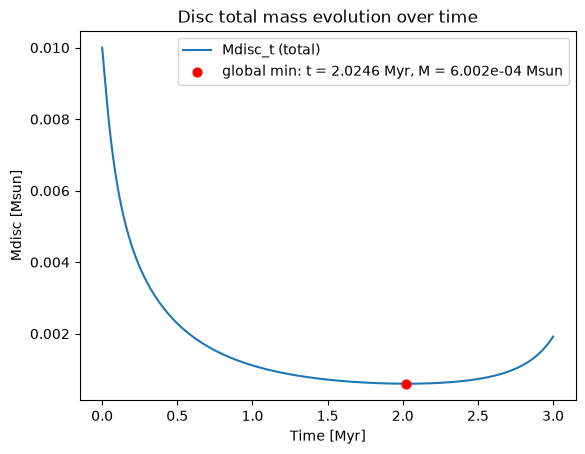

In [16]:
from DiscEvolution.constants import Msun
Mdisc_t_array = np.array(Mdisc_t)             # [g]
Mdisc_t_in_Msun = Mdisc_t_array / Msun        # [g] -> [Msun]

# CHANGED: x-axis now uses t_Myr ([Myr]) instead of t ([years]).
# The axis label already said "Time [Myr]" but the data was in years, so the
# ticks were off by 1e6. t_Myr = t / 1e6 is defined in the extraction cell.
plt.plot(t_Myr, Mdisc_t_in_Msun, label="Mdisc_t (total)")

# NEW: mark the global minimum of the total disc mass, computed in the t_min cell:
#   t_min_Myr       [Myr]   time of the minimum (= t_min [yr] / 1e6)
#   Mdisc_min_Msun  [Msun]  disc mass at that time
# zorder=3 draws the marker on top of the line.
plt.scatter(t_min_Myr, Mdisc_min_Msun, color="red", marker="o", s=40, zorder=3,
            label=f"global min: t = {t_min_Myr:.4f} Myr, M = {Mdisc_min_Msun:.3e} Msun")

plt.title("Disc total mass evolution over time")
plt.ylabel("Mdisc [Msun]")
plt.xlabel("Time [Myr]")
plt.legend()



Text(0.5, 0, 'Time [Myr]')

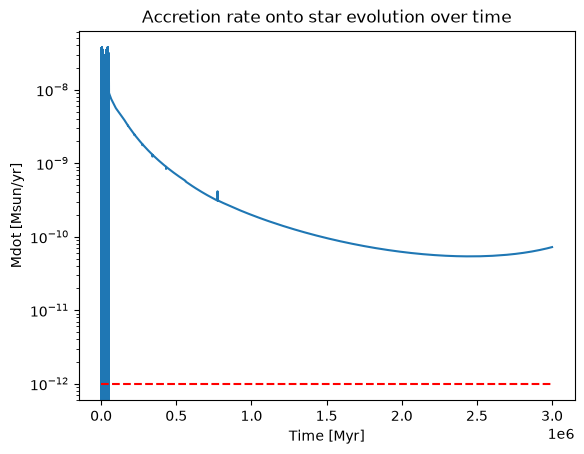

In [18]:
plt.plot(t, Mdot_t)
plt.title("Accretion rate onto star evolution over time")
plt.hlines(1e-12, 0.0, 3e6, colors="red", linestyles= "dashed")

plt.yscale("log")
plt.xscale("linear")
plt.ylabel("Mdot [Msun/yr]")
plt.xlabel("Time [Myr]")


Dropping 8 trailing point(s) that don't fill a full 20-point block


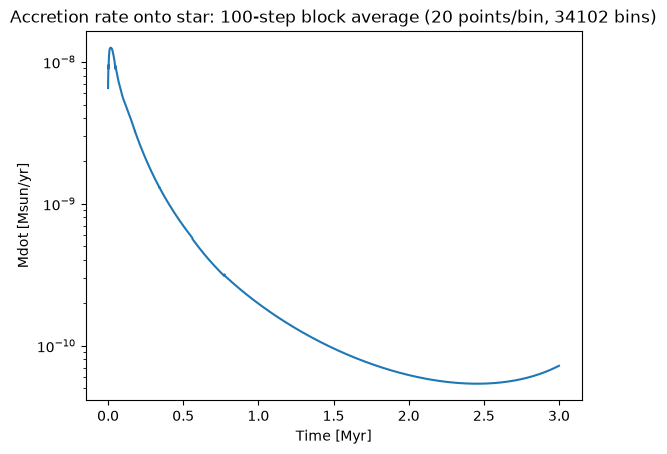

In [19]:
# Plot the average Mdot over every n=100 simulation steps
#
# disk_Mdot_star (Mdot_t) is written every 5 steps -- see run_model_Hof.py's
# _integrate(): `if (n % 5 == 0): grow_and_set(h5f["disk_Mdot_star"], ...)`.
# So n=100 simulation steps = 100/5 = 20 consecutive Mdot_t entries: each
# point on this plot IS the mean of 20 consecutive points from the log-Mdot
# plot above. This is a non-overlapping BLOCK average (decimation) -- one
# output point per 20 input points -- not a rolling/moving average (which
# `uniform_filter1d`, already imported in the first cell, would give: one
# smoothed output point per INPUT point instead).

STEPS_PER_WRITE = 5                          # cadence disk_Mdot_star is written at (run_model_Hof.py)
N_STEPS = 100                                # simulation steps to average over per output point
assert N_STEPS % STEPS_PER_WRITE == 0, "N_STEPS must be a multiple of STEPS_PER_WRITE"
block = N_STEPS // STEPS_PER_WRITE           # = 20 consecutive Mdot_t entries per output point

Mdot_t_arr = np.asarray(Mdot_t, dtype=float)   # [Msun/yr]
t_Myr_arr  = np.asarray(t_Myr, dtype=float)    # [Myr]

n_blocks = len(Mdot_t_arr) // block
n_dropped = len(Mdot_t_arr) - n_blocks * block
if n_dropped:
    print(f"Dropping {n_dropped} trailing point(s) that don't fill a full {block}-point block")

# Average of Mdot, and of the matching time values, within each block  [Msun/yr], [Myr]
Mdot_block_avg = Mdot_t_arr[:n_blocks * block].reshape(n_blocks, block).mean(axis=1)
t_block_avg    = t_Myr_arr[:n_blocks * block].reshape(n_blocks, block).mean(axis=1)

plt.plot(t_block_avg, Mdot_block_avg, '-')
plt.yscale("log")
plt.title(f"Accretion rate onto star: {N_STEPS}-step block average ({block} points/bin, {n_blocks} bins)")
plt.ylabel("Mdot [Msun/yr]")
plt.xlabel("Time [Myr]")
plt.show()


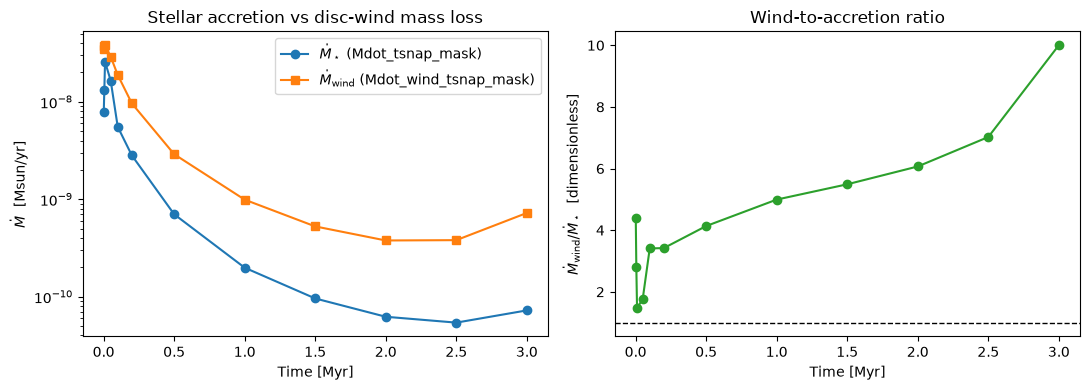

median wind/accretion ratio: 4.264  (range 1.480-10.003)


In [21]:
# Compare Mdot_tsnap_mask (accretion onto star) with Mdot_wind_tsnap_mask (disc-wind mass loss).
#
# Both come straight from integrate_wind_mass_loss_rate() in the
# "erad / t_snap_mask / Mdot_tsnap ..." cell above. That function returns the two
# rates already:
#   - PAIRED and masked to finite & strictly-positive values (the SAME mask on
#     both), so element i of each refers to the same snapshot;
#   - together with t_snap_mask, the matching snapshot times, so they can be
#     plotted against time. All three arrays therefore have equal length.
# (No physics is recomputed here -- see the diagnostic cell above for the
#  unmasked, per-snapshot recomputation.)
#
# Units:
#   Mdot_tsnap_mask       stellar accretion rate       [Msun/yr]
#   Mdot_wind_tsnap_mask   integrated disc-wind loss    [Msun/yr]
#   t_snap_mask            snapshot time                [Myr]
#   ratio                  wind / accretion             [dimensionless]
if _psi != 0:
      ratio = Mdot_wind_tsnap_mask / Mdot_tsnap_mask          # [dimensionless]

      fig, axes = plt.subplots(1, 2, figsize=(11, 4))

      # (1) both rates vs time   [Msun/yr  vs  Myr]
      ax = axes[0]
      ax.plot(t_snap_mask, Mdot_tsnap_mask,      'o-', label=r'$\dot{M}_\star$ (Mdot_tsnap_mask)')
      ax.plot(t_snap_mask, Mdot_wind_tsnap_mask, 's-', label=r'$\dot{M}_{\rm wind}$ (Mdot_wind_tsnap_mask)')
      ax.set_yscale('log')
      ax.set_xlabel("Time [Myr]")
      ax.set_ylabel(r"$\dot{M}$  [Msun/yr]")
      ax.set_title("Stellar accretion vs disc-wind mass loss")
      ax.legend()

      # (2) wind-to-accretion ratio vs time   [dimensionless  vs  Myr]
      ax = axes[1]
      ax.plot(t_snap_mask, ratio, 'o-', color='C2')
      ax.axhline(1.0, color='k', ls='--', lw=1)   # ratio = 1: wind loss balances accretion onto the star
      ax.set_xlabel("Time [Myr]")
      ax.set_ylabel(r"$\dot{M}_{\rm wind} / \dot{M}_\star$  [dimensionless]")
      ax.set_title("Wind-to-accretion ratio")

      plt.tight_layout()
      plt.show()

      print(f"median wind/accretion ratio: {np.median(ratio):.3f}  "
            f"(range {ratio.min():.3f}-{ratio.max():.3f})")


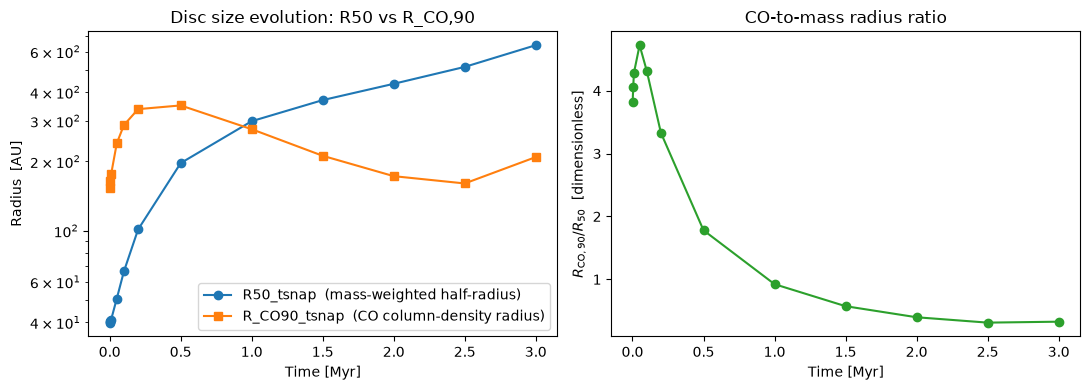

In [22]:
# Compare the evolution of R50_tsnap (mass-weighted half-radius) and
# R_CO90_tsnap (CO-column-density-threshold radius, Trapman et al. 2023 Eq. 3).

# Both are radii in AU, aligned to t_snap [Myr] 
# Profile-derived series plot against t_snap, not the dense `t` grid. 
# R_CO90_tsnap is expected to be gaps (NaN) at
# the first/last snapshot -- see the "R_CO,90" cell above for why.

ratio_CO90_50 = R_CO90_tsnap / R50_tsnap   # [dimensionless]

fig, axes = plt.subplots(1, 2, figsize=(11, 4))

# (1) both radii vs time   [AU  vs  Myr]
ax = axes[0]
ax.plot(t_snap, R50_tsnap,   'o-', label='R50_tsnap  (mass-weighted half-radius)')
ax.plot(t_snap, R_CO90_tsnap, 's-', label='R_CO90_tsnap  (CO column-density radius)')
ax.set_yscale('log')
ax.set_xlabel("Time [Myr]")
ax.set_ylabel("Radius  [AU]")
ax.set_title("Disc size evolution: R50 vs R_CO,90")
ax.legend()

# (2) R_CO90 / R50 ratio vs time   [dimensionless  vs  Myr]
ax = axes[1]
ax.plot(t_snap, ratio_CO90_50, 'o-', color='C2')
ax.set_xlabel("Time [Myr]")
ax.set_ylabel(r"$R_{\rm CO,90} / R_{50}$  [dimensionless]")
ax.set_title("CO-to-mass radius ratio")

plt.tight_layout()
plt.show()


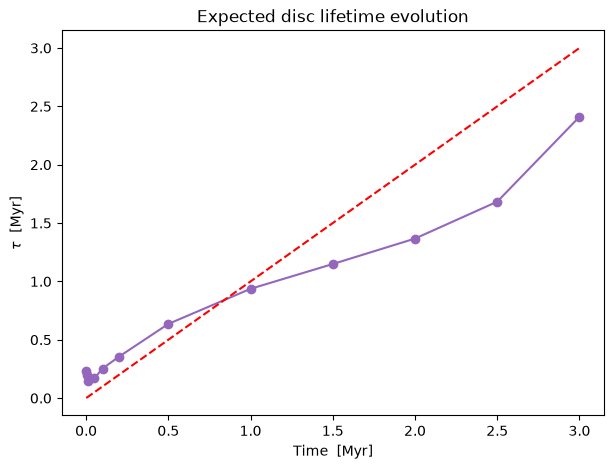

In [23]:
# Plot that shows time evolution of expected disc lifetime tau 

# tau_Myr (from the "tau" cell above) is aligned to t_snap_mask [Myr] -- the subset
# of snapshots where both Mdot_tsnap_mask and Mdot_wind_tsnap_mask are defined (see
# that cell's comments for why the first/last snapshot are dropped). tau itself is
# the instantaneous depletion timescale disc mass / (accretion + wind loss) [Myr];
# a rising tau over time means the total mass-loss rate is falling faster than the
# disc mass itself -- i.e. the disc is depleting more slowly, in relative terms, as
# it evolves.

fig, ax = plt.subplots(figsize=(7, 5))
if _psi != 0:
    ax.plot(t_snap_mask, tau_Myr, 'o-', color='C4')
    ax.plot(t_snap_mask, t_snap_mask, '--', color = "red")
else:
    ax.plot(t_snap, tau_Myr, 'o-', color='C4')
    ax.plot(t_snap, t_snap, '--', color = "red")

ax.set_xlabel("Time  [Myr]")
ax.set_ylabel(r"$\tau$  [Myr]")
ax.set_title("Expected disc lifetime evolution")
plt.show()


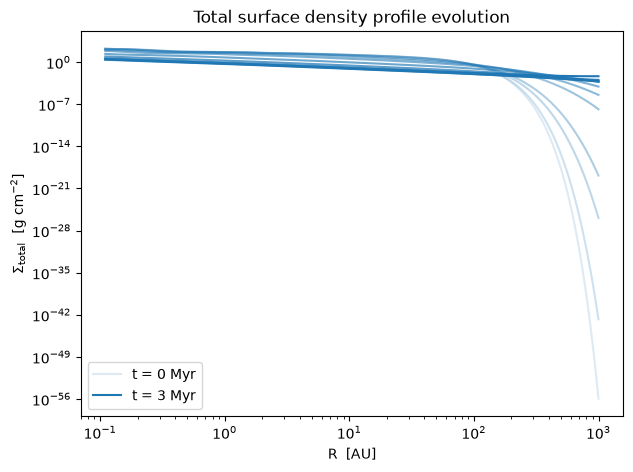

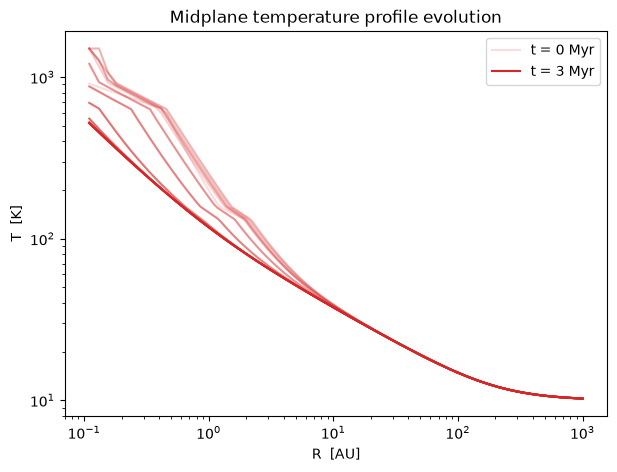

In [24]:
# A series of more in-depth plots analogous to Figure 4,5 in Balogh et al. 2026
# where we study several observables as a function of radius,
# including Sigma, T. Add series for every time snapshot, with color same color but 
# opacity increasing over time.
# Each observable has a separate figure

# Shared time-opacity convention for all three figures below: every line in a given
# figure uses the SAME base color (one color per observable/population), and only
# the alpha (opacity) changes with snapshot -- faint/light = early time, fully
# opaque = the most recent snapshot.

R_au = np.asarray(data["R"], dtype=float)      # [AU]
n_snap = len(t_snap)
alphas = np.linspace(0.15, 1.0, n_snap)        # opacity ramp: faint (early) -> opaque (late)

def _time_label(i, prefix=""):
    """Legend label for the first/last snapshot only; None (no legend entry) otherwise."""
    if i == 0:
        return f"{prefix}t = {t_snap[i]:.3g} Myr"
    if i == n_snap - 1:
        return f"{prefix}t = {t_snap[i]:.3g} Myr"
    return None


# ---------------------------------------------------------------------------
# Figure 1: Sigma(R) -- total (gas+dust) surface density, one line per snapshot
# ---------------------------------------------------------------------------
# Uses Sigma_total_tsnap from the "tau" cell above (full mass, not gas-only
# Sigma_G) -- units [g/cm^2]. Swap in data["Sigma_G"] instead if gas-only is
# wanted.
fig1, ax1 = plt.subplots(figsize=(7, 5))
color_sigma = "C0"
for i in range(n_snap):
    ax1.plot(R_au, Sigma_total_tsnap[i], color=color_sigma, alpha=alphas[i],
              label=_time_label(i))
ax1.set_xscale("log")
ax1.set_yscale("log")
ax1.set_xlabel("R  [AU]")
ax1.set_ylabel(r"$\Sigma_{\rm total}$  [g cm$^{-2}$]")
ax1.set_title("Total surface density profile evolution")
ax1.legend()
plt.show()


# ---------------------------------------------------------------------------
# Figure 2: T(R) -- midplane temperature, one line per snapshot
# ---------------------------------------------------------------------------
Temp_tsnap = np.asarray(data["T"], dtype=float)   # [K], one row per t_snap
fig2, ax2 = plt.subplots(figsize=(7, 5))
color_T = "C3"
for i in range(n_snap):
    ax2.plot(R_au, Temp_tsnap[i], color=color_T, alpha=alphas[i],
              label=_time_label(i))
ax2.set_xscale("log")
ax2.set_yscale("log")
ax2.set_xlabel("R  [AU]")
ax2.set_ylabel("T  [K]")
ax2.set_title("Midplane temperature profile evolution")
ax2.legend()
plt.show()


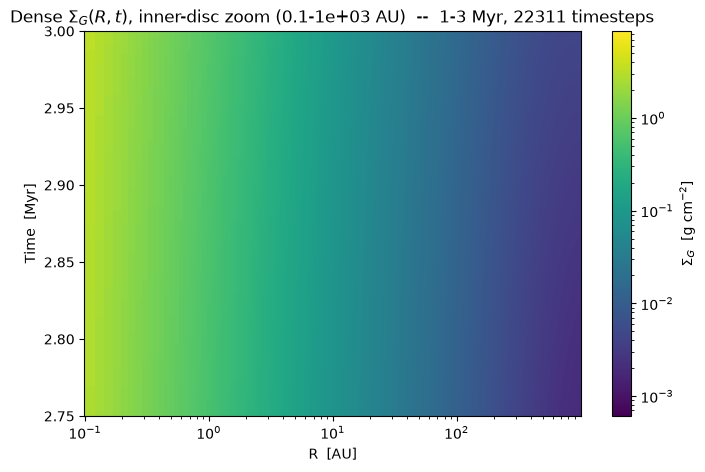

In [25]:
# Add plot for dense array(s) of Sigma -- one heatmap per densely-exported
# variable
#
# "<name>_dense" / "<name>_dense_t" (data loaded by load_data() above, one
# pair per entry in data["dense_names"]) only exist in output from
# run_model_Hof_dense.py (filename contains "_dense_") -- they give
# <name>(R) at FULL time resolution (a candidate write every 5 steps, same
# cadence as disk_Mdot_star/disk_Mass/Tc/Sigc) within the
# [DENSE_T_MIN_MYR, DENSE_T_MAX_MYR] window that run was configured with,
# e.g. thousands of rows -- vs. the 13-point time_snap grid every other
# profile (Sigma_G, T, ...) is stuck with. run_model_Hof_dense.py's
# DENSE_VARIABLES list controls how many/which observables get densely
# exported; the file currently loaded has DENSE_VARIABLES =
# ["Sigma_G", "Sigma_dust", "Sigma_pebbles"] (CHANGED: this cell used to
# assume only Sigma_G_dense existed and drew a single heatmap -- it now
# loops over data["dense_names"] so it keeps working regardless of how many
# dense variables a given run exported).
#
# That many rows is too many to overlay as individual lines (unlike the
# sparse per-snapshot Sigma(R) figure above, which uses one line per t_snap
# with an opacity ramp) -- so each variable is rendered as its own separate
# 2D heatmap:
#   x = R                  [AU]
#   y = <name>_dense_t     [Myr]   (its OWN timestamps -- do not use t_snap here)
#   color = <name>_dense   [g/cm^2 for Sigma_* -- log-scaled: spans several orders of magnitude]
#
# ZOOMED to a small radial window just outside the grid's inner edge
# (R > R_ZOOM_MIN, R_ZOOM_MIN just above 0.1 AU = grid rmin -- see
# DiscConfig_Hof_baseline.json / DiscConfig_Hof_sweep.json's grid.rmin) so any
# fluctuations near the inner boundary (inner-boundary-condition artifacts,
# grid-resolution effects, etc.) are easier to see than in the full 0.1-1000
# AU view above. Adjust R_ZOOM_MIN / R_ZOOM_MAX below to widen/narrow/shift
# the window; it applies to every dense variable's heatmap.

# LaTeX label for each known dense-variable name's colorbar/title; falls back
# to the raw name (with underscores) for anything not listed here, so a
# future DENSE_VARIABLES entry (e.g. "T") still plots without edits.
_DENSE_VAR_LABELS = {
    "Sigma_G": r"$\Sigma_G$",
    "Sigma_dust": r"$\Sigma_{\rm dust}$",
    "Sigma_pebbles": r"$\Sigma_{\rm pebbles}$",
}

dense_names = data.get("dense_names", [])   # e.g. ["Sigma_G", "Sigma_dust", "Sigma_pebbles"]

if not dense_names:
    print("This file has no dense datasets -- point `filename` (a few cells "
          "above) at a run_model_Hof_dense.py output (filename contains "
          "'_dense_') to use this cell.")
else:
    R_ZOOM_MIN = 0.1   # [AU] -- just above the grid's inner edge (rmin)
    R_ZOOM_MAX = 1000.0   # [AU] -- upper edge of the zoomed-in window

    R_au_full = np.asarray(data["R"], dtype=float)                # [AU]
    in_zoom = (R_au_full > R_ZOOM_MIN) & (R_au_full <= R_ZOOM_MAX)  # boolean mask over the radial grid
    R_au = R_au_full[in_zoom]                                      # [AU], zoomed-in radial grid

    for dense_name in dense_names:
        t_dense_Myr = np.asarray(data[f"{dense_name}_dense_t"], dtype=float) / 1e6   # [years] -> [Myr]
        dense_full = np.asarray(data[f"{dense_name}_dense"], dtype=float)            # [g/cm^2], (n_dense, nR)
        dense_zoom = dense_full[:, in_zoom]                                          # [g/cm^2], (n_dense, n_zoom_cells)

        positive = dense_zoom[dense_zoom > 0]   # LogNorm needs strictly-positive bounds
        vmin, vmax = positive.min(), positive.max()

        var_label = _DENSE_VAR_LABELS.get(dense_name, dense_name)

        fig, ax = plt.subplots(figsize=(8, 5))
        pcm = ax.pcolormesh(R_au, t_dense_Myr, dense_zoom,
                             norm=LogNorm(vmin=vmin, vmax=vmax),
                             shading="auto", cmap="viridis")
        ax.set_xscale("log")
        ax.set_xlabel("R  [AU]")
        ax.set_ylabel("Time  [Myr]")
        ax.set_ylim(2.75,3.0)
        ax.set_title(f"Dense {var_label}$(R,t)$, inner-disc zoom "
                     f"({R_ZOOM_MIN:.3g}-{R_ZOOM_MAX:.3g} AU)  --  "
                     f"{t_dense_Myr[0]:.3g}-{t_dense_Myr[-1]:.3g} Myr, "
                     f"{dense_zoom.shape[0]} timesteps")
        cbar = fig.colorbar(pcm, ax=ax)
        cbar.set_label(var_label + r"  [g cm$^{-2}$]")
        plt.show()


Dense mass integration complete -- rows per variable in window: {'Sigma_G': 2789}


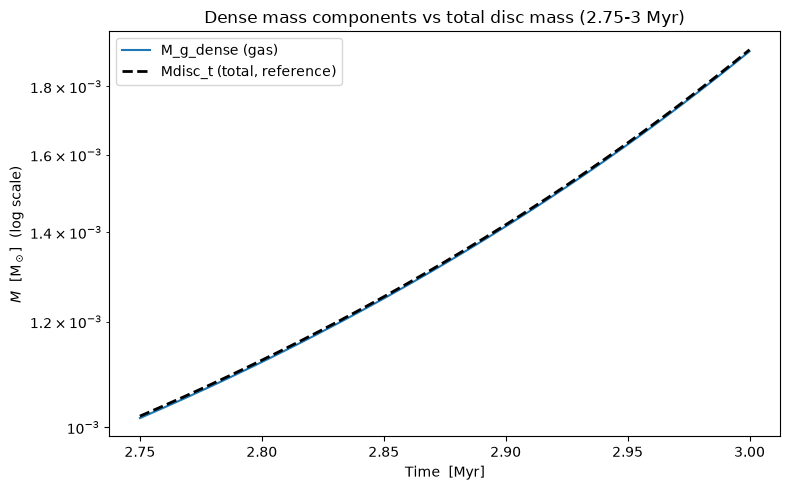

In [26]:
# Calculate three dense mass variables: M_g_dense, M_dust_dense, M_pebbles_dense
# by integrating their respective dense Sigma variables at each time they are evaluated
# Plot the three masses over the same time interval as specified in the cell above
# with log(M) as y-axis and time as the x-axis. Include Mdisc_t as the reference.
# Goal is to see which component of the disc mass leads to upwards trend of Mdisc_t
# in final stages of the evolution

# Time window to restrict to -- SAME window as the y-axis limits set on the dense
# heatmap cell above (ax.set_ylim(2.75, 3.0)), so this plot zooms into the same
# late-evolution window where Mdisc_t is seen to trend upward.
T_WINDOW_MIN_MYR = 2.75   # [Myr]
T_WINDOW_MAX_MYR = 3.0    # [Myr]

# Full radial grid -- NOT the R_ZOOM_MIN/R_ZOOM_MAX subset from the cell above,
# since that's only a plotting zoom for the heatmaps; a mass integral needs the
# WHOLE disc to be comparable to Mdisc_t (the total-mass reference plotted below).
R_full = np.asarray(data["R"], dtype=float)   # [AU]

# Label each dense variable's integrated mass for the legend below.
_DENSE_MASS_LABELS = {
    "Sigma_G": "M_g_dense (gas)",
    "Sigma_dust": "M_dust_dense (small grains)",
    "Sigma_pebbles": "M_pebbles_dense (pebbles)",
}

dense_masses_Msun = {}   # dense_name -> (t_window [Myr], M_window [Msun])
for dense_name in dense_names:
    t_dense_Myr = np.asarray(data[f"{dense_name}_dense_t"], dtype=float) / 1e6   # [years] -> [Myr]
    Sigma_dense = np.asarray(data[f"{dense_name}_dense"], dtype=float)            # [g/cm^2], (n_dense, nR)

    # Restrict to the time window BEFORE integrating -- cheaper than integrating
    # every one of the ~20k dense rows and matches the cell-above time window.
    in_window = (t_dense_Myr >= T_WINDOW_MIN_MYR) & (t_dense_Myr <= T_WINDOW_MAX_MYR)
    t_window = t_dense_Myr[in_window]              # [Myr]
    Sigma_window = Sigma_dense[in_window]           # [g/cm^2], (n_window, nR)

    # Mass(t) = integral of 2*pi*R*Sigma(R,t) dR -- same convention as Mgas_tsnap /
    # Mdisc_tsnap above: trapezoid over R [AU], * AU**2 converts cm^2 -> g, / Msun -> Msun.
    integrand = Sigma_window * (2 * np.pi * R_full)[np.newaxis, :]           # [g/cm^2 * AU], (n_window, nR)
    M_window_Msun = np.trapezoid(integrand, R_full, axis=1) * AU**2 / Msun   # [Msun], (n_window,)

    dense_masses_Msun[dense_name] = (t_window, M_window_Msun)

print("Dense mass integration complete -- rows per variable in window:",
      {name: arr[1].shape[0] for name, arr in dense_masses_Msun.items()})

# --- Plot: M [Msun] (log y-axis) vs time [Myr], restricted to T_WINDOW, with
#     Mdisc_t (total disc mass, g -> Msun) plotted as reference ---
fig, ax = plt.subplots(figsize=(8, 5))

for dense_name, (t_window, M_window_Msun) in dense_masses_Msun.items():
    ax.plot(t_window, M_window_Msun, label=_DENSE_MASS_LABELS.get(dense_name, dense_name))

# Reference: total disc mass Mdisc_t (data["disk_Mass"], [g], aligned to t_Myr),
# restricted to the same time window and converted g -> Msun to match the dense
# mass series above.
Mdisc_t_Msun = np.asarray(Mdisc_t, dtype=float) / Msun   # [g] -> [Msun]
in_window_Mdisc = (t_Myr >= T_WINDOW_MIN_MYR) & (t_Myr <= T_WINDOW_MAX_MYR)
ax.plot(t_Myr[in_window_Mdisc], Mdisc_t_Msun[in_window_Mdisc],
        'k--', lw=2, label="Mdisc_t (total, reference)")

ax.set_yscale("log")
ax.set_xlabel("Time  [Myr]")
ax.set_ylabel(r"$M$  [M$_\odot$]  (log scale)")
ax.set_title(f"Dense mass components vs total disc mass "
             f"({T_WINDOW_MIN_MYR:.3g}-{T_WINDOW_MAX_MYR:.3g} Myr)")
ax.legend()
plt.tight_layout()
plt.show()


Cutoff radius R_cut = 100 AU
Start row: t = 2.024643 Myr (t_min = 2.024603 Myr)
End row:   t = 2.999965 Myr
region                   M(t_min) [Msun]     M(end) [Msun]     dM [Msun]   dM/M(t_min)
inner (R < 100 AU)          7.009385e-05      9.350832e-05     2.341e-05     3.340e-01
outer (R >= 100 AU)         5.251067e-04      1.818849e-03     1.294e-03     2.464e+00
total                       5.952005e-04      1.912358e-03     1.317e-03     2.213e+00
Check: Mdisc_t change over the same interval = 1.317e-03 Msun


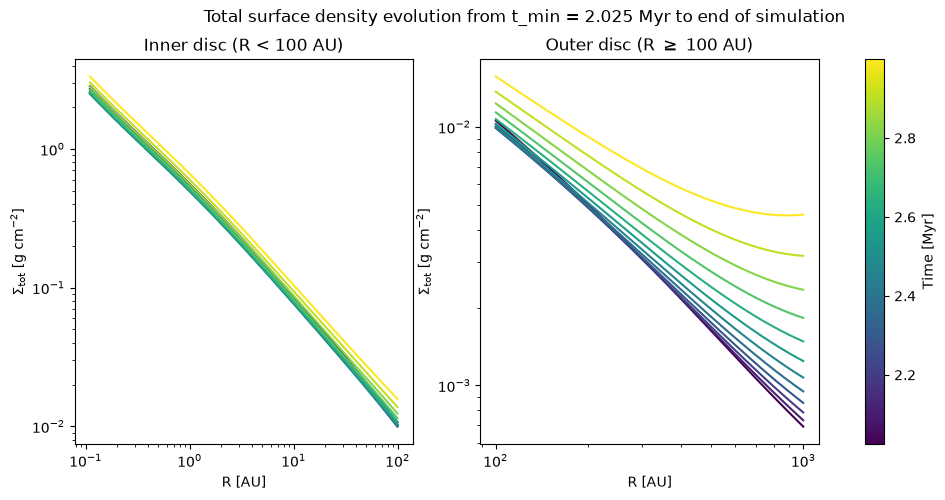

In [27]:

# Separate inner disc from outer disc and see if increase of mass happens preferentially within 
# some window of the disc radius

# Initial cutoff radius: r = 100 AU

# Plot evolution of Sigma from t_min to end of simulation for both windows (inner and outer)
# Integrate Sigma at t_min and end of simulation, print difference of total mass in each region

# ---------------------------------------------------------------------------
# Inputs (all defined in earlier cells):
#   t_min                         [years]   time of global minimum of Mdisc_t (t_min cell)
#   data["R"]                     [AU]      radial grid (1000 cells, 0.1-1000 AU)
#   data["<name>_dense"]          [g/cm^2]  Sigma(R) at full output cadence, shape (n_dense, nR)
#   data["<name>_dense_t"]        [years]   timestamps of each dense row
#   dense_names                   list of dense variables loaded, e.g. ["Sigma_G", "Sigma_dust", "Sigma_pebbles"]
#
# Mdisc_t (data["disk_Mass"]) is TOTAL mass (gas + dust), so Sigma here is the SUM of
# every loaded dense Sigma variable. If only "Sigma_G" was loaded (see the
# load_data(..., dense_variables=...) call near the top), this is GAS ONLY -- a
# warning is printed in that case. Pass dense_variables=None to load all of them.
# ---------------------------------------------------------------------------

R_CUT_AU = 100.0   # [AU] cutoff radius: inner = R < R_CUT_AU, outer = R >= R_CUT_AU

R_full = np.asarray(data["R"], dtype=float)   # [AU], full grid -- mass integrals need the whole disc

# --- Total Sigma = sum of all loaded dense Sigma variables, on the common dense time grid ---
t_dense_yr = np.asarray(data[f"{dense_names[0]}_dense_t"], dtype=float)   # [years]
Sigma_tot_dense = np.zeros((t_dense_yr.size, R_full.size))                # [g/cm^2], (n_dense, nR)
for dense_name in dense_names:
    # All dense variables are written at the same step, so their timestamps must match
    assert np.array_equal(np.asarray(data[f"{dense_name}_dense_t"], dtype=float), t_dense_yr), \
        f"{dense_name}_dense_t differs from {dense_names[0]}_dense_t -- cannot sum them"
    Sigma_tot_dense += np.asarray(data[f"{dense_name}_dense"], dtype=float)
if set(dense_names) != {"Sigma_G", "Sigma_dust", "Sigma_pebbles"}:
    print(f"WARNING: Sigma below is the sum of {dense_names} only -- not gas + all dust, "
          "so masses will NOT be directly comparable with Mdisc_t.")

# --- Restrict dense rows to [t_min, end of simulation] ---
if t_min < t_dense_yr[0]:
    raise ValueError(f"t_min = {t_min/1e6:.4f} Myr is before the dense window starts "
                     f"({t_dense_yr[0]/1e6:.4f} Myr) -- re-run with a wider dense window.")
after_tmin = t_dense_yr >= t_min
t_win_Myr = t_dense_yr[after_tmin] / 1e6          # [Myr]
Sigma_win = Sigma_tot_dense[after_tmin]           # [g/cm^2], (n_win, nR)

# --- Mass in each region: M = integral of 2*pi*R*Sigma dR ---
# Trapezoid rule done interval by interval, so every interval [R_i, R_i+1] belongs to
# exactly ONE region (by its midpoint). This way M_inner + M_outer equals the full-disc
# integral exactly, with no double counting or missing interval at R_CUT_AU.
# Same unit convention as the other mass cells: R in [AU], * AU**2 -> [g], / Msun -> [Msun].
def region_masses_Msun(Sigma_rows):
    """Sigma_rows [g/cm^2], shape (n, nR) -> (M_inner, M_outer) [Msun], each shape (n,)."""
    f = 2 * np.pi * R_full[np.newaxis, :] * Sigma_rows           # [g/cm^2 * AU]
    dM = 0.5 * (f[:, 1:] + f[:, :-1]) * np.diff(R_full)          # [g/cm^2 * AU^2], per interval
    inner_interval = 0.5 * (R_full[1:] + R_full[:-1]) < R_CUT_AU  # interval midpoint inside cutoff
    M_in = dM[:, inner_interval].sum(axis=1) * AU**2 / Msun       # [Msun]
    M_out = dM[:, ~inner_interval].sum(axis=1) * AU**2 / Msun     # [Msun]
    return M_in, M_out

M_in_Msun, M_out_Msun = region_masses_Msun(Sigma_win[[0, -1]])   # rows: first dense row after t_min, last row

# --- Print mass change per region between t_min and end of simulation ---
dM_in, dM_out = M_in_Msun[1] - M_in_Msun[0], M_out_Msun[1] - M_out_Msun[0]   # [Msun]
print(f"Cutoff radius R_cut = {R_CUT_AU:g} AU")
print(f"Start row: t = {t_win_Myr[0]:.6f} Myr (t_min = {t_min/1e6:.6f} Myr)")
print(f"End row:   t = {t_win_Myr[-1]:.6f} Myr")
print(f"{'region':<22}{'M(t_min) [Msun]':>18}{'M(end) [Msun]':>18}{'dM [Msun]':>14}{'dM/M(t_min)':>14}")
for name, M, dM in [(f"inner (R < {R_CUT_AU:g} AU)", M_in_Msun, dM_in),
                    (f"outer (R >= {R_CUT_AU:g} AU)", M_out_Msun, dM_out),
                    ("total", M_in_Msun + M_out_Msun, dM_in + dM_out)]:
    print(f"{name:<22}{M[0]:>18.6e}{M[1]:>18.6e}{dM:>14.3e}{dM / M[0]:>14.3e}")

# Sanity check: the total from dense Sigma should track Mdisc_t (data["disk_Mass"], [g]) over the same interval
Mdisc_t_Msun = np.asarray(Mdisc_t, dtype=float) / Msun             # [Msun]
t_yr_arr = np.asarray(t, dtype=float)                              # [years]
i0 = int(np.argmin(np.abs(t_yr_arr - t_win_Myr[0] * 1e6)))
i1 = int(np.argmin(np.abs(t_yr_arr - t_win_Myr[-1] * 1e6)))
print(f"Check: Mdisc_t change over the same interval = {Mdisc_t_Msun[i1] - Mdisc_t_Msun[i0]:.3e} Msun")

# --- Plot Sigma(R) evolution from t_min to end, one panel per region ---
# ~thousands of dense rows after t_min: plot N_CURVES of them, evenly spaced in time,
# coloured by time [Myr] (dark = t_min, bright = end).
N_CURVES = 12
idx = np.unique(np.linspace(0, t_win_Myr.size - 1, N_CURVES).round().astype(int))
cmap = plt.cm.viridis
norm = mpl.colors.Normalize(vmin=t_win_Myr[0], vmax=t_win_Myr[-1])   # [Myr]
inner_R = R_full < R_CUT_AU

fig, (ax_in, ax_out) = plt.subplots(1, 2, figsize=(12, 5))
for i in idx:
    c = cmap(norm(t_win_Myr[i]))
    ax_in.plot(R_full[inner_R], Sigma_win[i, inner_R], color=c)
    ax_out.plot(R_full[~inner_R], Sigma_win[i, ~inner_R], color=c)

for ax, title in [(ax_in, f"Inner disc (R < {R_CUT_AU:g} AU)"),
                  (ax_out, f"Outer disc (R $\\geq$ {R_CUT_AU:g} AU)")]:
    ax.set_xscale("log")
    ax.set_yscale("log")
    ax.set_xlabel("R [AU]")
    ax.set_ylabel(r"$\Sigma_{\rm tot}$ [g cm$^{-2}$]")
    ax.set_title(title)

fig.colorbar(mpl.cm.ScalarMappable(norm=norm, cmap=cmap), ax=[ax_in, ax_out], label="Time [Myr]")
fig.suptitle(f"Total surface density evolution from t_min = {t_min/1e6:.3f} Myr to end of simulation")
plt.show()


Sigma_G: dense row 11430 at t = 2.024643 Myr (offset from t_min = +40.3 yr)


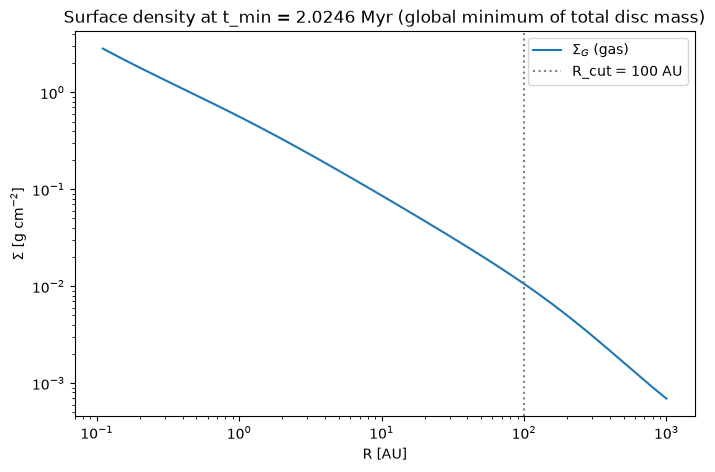

In [28]:
# Plot the Sigma radial distribution at t_min (time of global minimum of total disc mass)
#
# Inputs (all defined in earlier cells):
#   t_min                    [years]   time of global minimum of Mdisc_t (t_min cell)
#   data["R"]                [AU]      radial grid
#   data["<name>_dense"]     [g/cm^2]  Sigma(R) at full output cadence, shape (n_dense, nR)
#   data["<name>_dense_t"]   [years]   timestamps of each dense row
#   dense_names              list of dense variables loaded, e.g. ["Sigma_G", "Sigma_dust", "Sigma_pebbles"]
#
# Uses the DENSE Sigma output (not the 13-point t_snap profiles), since t_min generally
# falls between snapshots. The dense row closest in time to t_min is plotted; the time
# offset between that row and t_min is printed so the match can be checked.
# One line per loaded dense variable, plus their sum (Sigma_tot) when more than one is
# loaded. The cutoff radius from the inner/outer cell above (R_CUT_AU [AU]) is marked
# for reference, if that cell has been run.

R_au_tmin = np.asarray(data["R"], dtype=float)   # [AU]

# Labels for each known dense variable; falls back to the raw name for anything else
_SIGMA_TMIN_LABELS = {
    "Sigma_G": r"$\Sigma_G$ (gas)",
    "Sigma_dust": r"$\Sigma_{\rm dust}$ (small grains)",
    "Sigma_pebbles": r"$\Sigma_{\rm pebbles}$ (pebbles)",
}

fig, ax = plt.subplots(figsize=(8, 5))
Sigma_tot_tmin = np.zeros_like(R_au_tmin)   # [g/cm^2], running sum over dense variables
for dense_name in dense_names:
    t_dense_yr_tmin = np.asarray(data[f"{dense_name}_dense_t"], dtype=float)   # [years]
    if not (t_dense_yr_tmin[0] <= t_min <= t_dense_yr_tmin[-1]):
        raise ValueError(f"t_min = {t_min/1e6:.4f} Myr is outside the dense window of {dense_name} "
                         f"({t_dense_yr_tmin[0]/1e6:.4f}-{t_dense_yr_tmin[-1]/1e6:.4f} Myr)")
    j_tmin = int(np.argmin(np.abs(t_dense_yr_tmin - t_min)))                   # nearest dense row to t_min
    Sigma_tmin = np.asarray(data[f"{dense_name}_dense"][j_tmin], dtype=float)  # [g/cm^2], shape (nR,)
    Sigma_tot_tmin += Sigma_tmin
    print(f"{dense_name}: dense row {j_tmin} at t = {t_dense_yr_tmin[j_tmin]/1e6:.6f} Myr "
          f"(offset from t_min = {t_dense_yr_tmin[j_tmin] - t_min:+.1f} yr)")
    ax.plot(R_au_tmin, Sigma_tmin, label=_SIGMA_TMIN_LABELS.get(dense_name, dense_name))

if len(dense_names) > 1:
    ax.plot(R_au_tmin, Sigma_tot_tmin, color="k", linestyle="--", label=r"$\Sigma_{\rm tot}$ (sum)")

# Mark the inner/outer cutoff radius [AU], if the inner/outer cell above has been run
if "R_CUT_AU" in globals():
    ax.axvline(R_CUT_AU, color="grey", linestyle=":", label=f"R_cut = {R_CUT_AU:g} AU")

ax.set_xscale("log")
ax.set_yscale("log")
ax.set_xlabel("R [AU]")
ax.set_ylabel(r"$\Sigma$ [g cm$^{-2}$]")
ax.set_title(f"Surface density at t_min = {t_min/1e6:.4f} Myr (global minimum of total disc mass)")
ax.legend()
plt.show()


101 frames, 1.000-3.000 Myr, t_min frame = dense row 11430 (t = 2.024643 Myr), GIF size = 0.58 MB


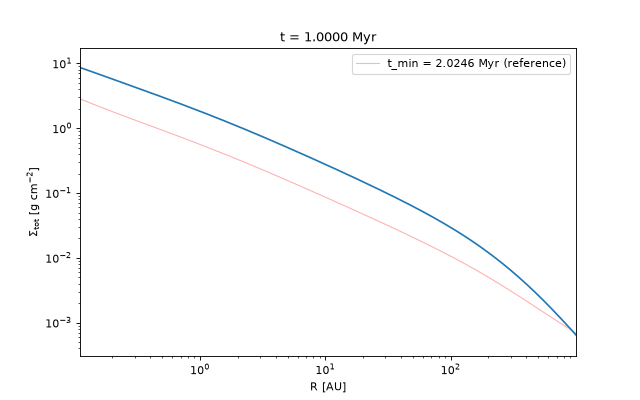

In [29]:
# GIF of the evolution of Sigma(R) over time, highlighting the frame at t_min
# (time of global minimum of total disc mass). The GIF is built entirely IN MEMORY
# (io.BytesIO buffer) and displayed inline -- nothing is written to disk.
#
# Inputs (all defined in earlier cells):
#   t_min                    [years]   time of global minimum of Mdisc_t (t_min cell)
#   data["R"]                [AU]      radial grid
#   data["<name>_dense"]     [g/cm^2]  Sigma(R) at full output cadence, shape (n_dense, nR)
#   data["<name>_dense_t"]   [years]   timestamps of each dense row
#   dense_names              list of dense variables loaded, e.g. ["Sigma_G", "Sigma_dust", "Sigma_pebbles"]
#
# Sigma plotted = SUM of every loaded dense Sigma variable (total, gas + dust, comparable
# to Mdisc_t) -- gas only if load_data(..., dense_variables=["Sigma_G"]) was used.
# Covers the whole dense window (DENSE_T_MIN_MYR - DENSE_T_MAX_MYR of the run).
#
# Highlighting of the t_min frame:
#   - the t_min frame is drawn in red, thicker, with "t = t_min" in the title
#   - it is held on screen longer (T_MIN_HOLD_MS) than normal frames (FRAME_MS)
#   - every OTHER frame shows the t_min profile as a faint red reference line, so the
#     evolution before/after the minimum can be compared against it

import io
from PIL import Image
from IPython.display import Image as IPyImage, display

N_FRAMES = 100        # number of frames, evenly spaced in time over the dense window
FRAME_MS = 80         # [ms] display duration of a normal frame
T_MIN_HOLD_MS = 1500  # [ms] display duration of the highlighted t_min frame
GIF_DPI = 80          # resolution of each frame (lower = smaller GIF in the notebook)

R_au_gif = np.asarray(data["R"], dtype=float)   # [AU]

# --- Total Sigma on the common dense time grid ---
t_dense_yr_gif = np.asarray(data[f"{dense_names[0]}_dense_t"], dtype=float)   # [years]
Sigma_tot_gif = np.zeros((t_dense_yr_gif.size, R_au_gif.size))               # [g/cm^2]
for dense_name in dense_names:
    assert np.array_equal(np.asarray(data[f"{dense_name}_dense_t"], dtype=float), t_dense_yr_gif), \
        f"{dense_name}_dense_t differs from {dense_names[0]}_dense_t -- cannot sum them"
    Sigma_tot_gif += np.asarray(data[f"{dense_name}_dense"], dtype=float)

if not (t_dense_yr_gif[0] <= t_min <= t_dense_yr_gif[-1]):
    raise ValueError(f"t_min = {t_min/1e6:.4f} Myr is outside the dense window "
                     f"({t_dense_yr_gif[0]/1e6:.4f}-{t_dense_yr_gif[-1]/1e6:.4f} Myr)")

# --- Choose frames: N_FRAMES rows evenly spaced in TIME, plus the row nearest t_min ---
j_tmin_gif = int(np.argmin(np.abs(t_dense_yr_gif - t_min)))   # dense row closest to t_min
t_targets = np.linspace(t_dense_yr_gif[0], t_dense_yr_gif[-1], N_FRAMES)                  # [years]
frame_rows = np.searchsorted(t_dense_yr_gif, t_targets).clip(0, t_dense_yr_gif.size - 1)
frame_rows = np.unique(np.append(frame_rows, j_tmin_gif))   # sorted, t_min row guaranteed included

Sigma_tmin_gif = Sigma_tot_gif[j_tmin_gif]   # [g/cm^2], reference profile at t_min

# --- Fixed axes across frames (so the curve motion is real, not axis rescaling) ---
positive = Sigma_tot_gif[frame_rows][Sigma_tot_gif[frame_rows] > 0]
fig, ax = plt.subplots(figsize=(8, 5), dpi=GIF_DPI)
ax.set_xscale("log")
ax.set_yscale("log")
ax.set_xlim(R_au_gif[0], R_au_gif[-1])
ax.set_ylim(positive.min() / 2, positive.max() * 2)
ax.set_xlabel("R [AU]")
ax.set_ylabel(r"$\Sigma_{\rm tot}$ [g cm$^{-2}$]")

ref_line, = ax.plot(R_au_gif, Sigma_tmin_gif, color="red", alpha=0.3, lw=1,
                    label=f"t_min = {t_min/1e6:.4f} Myr (reference)")
sigma_line, = ax.plot(R_au_gif, Sigma_tot_gif[frame_rows[0]], color="C0", lw=1.5)
gif_legend = ax.legend(loc="upper right")

# --- Render each frame into memory as a PIL image ---
frames, durations = [], []
for j in frame_rows:
    is_tmin = (j == j_tmin_gif)
    sigma_line.set_ydata(Sigma_tot_gif[j])
    sigma_line.set_color("red" if is_tmin else "C0")
    sigma_line.set_linewidth(3 if is_tmin else 1.5)
    ref_line.set_visible(not is_tmin)     # no need for the reference on the t_min frame itself
    gif_legend.set_visible(not is_tmin)   # ...nor its legend entry
    ax.set_title(f"t = {t_dense_yr_gif[j]/1e6:.4f} Myr" + ("   <-- t_min (global minimum of disc mass)" if is_tmin else ""),
                 color="red" if is_tmin else "black")
    fig.canvas.draw()
    frames.append(Image.fromarray(np.asarray(fig.canvas.buffer_rgba())).convert("RGB"))
    durations.append(T_MIN_HOLD_MS if is_tmin else FRAME_MS)
plt.close(fig)   # stop the last frame being displayed as a static figure too

# --- Encode the GIF into an in-memory buffer and display it (never touches disk) ---
gif_buffer = io.BytesIO()
frames[0].save(gif_buffer, format="GIF", save_all=True, append_images=frames[1:],
               duration=durations, loop=0)
print(f"{len(frames)} frames, {t_dense_yr_gif[frame_rows[0]]/1e6:.3f}-{t_dense_yr_gif[frame_rows[-1]]/1e6:.3f} Myr, "
      f"t_min frame = dense row {j_tmin_gif} (t = {t_dense_yr_gif[j_tmin_gif]/1e6:.6f} Myr), "
      f"GIF size = {gif_buffer.getbuffer().nbytes/1e6:.2f} MB")
display(IPyImage(data=gif_buffer.getvalue(), format="gif"))
